In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import pickle
# Load the dataset

In [3]:
data = pd.read_csv("bank-additional-full.csv", sep=";")
data.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:

selected_cols = [
    'age', #Ini artinya umur, yang merupakan variabel numerik.
    'job', #Ini artinya pekerjaan, yang merupakan variabel kategorikal.
    'marital', #Ini artinya status pernikahan, yang merupakan variabel kategorikal.
    'education', #Ini artinya pendidikan, yang merupakan variabel kategorikal.
    'housing', #Ini artinya apakah seseorang memiliki rumah atau tidak, yang merupakan variabel kategorikal.
    'loan', #Ini artinya apakah seseorang memiliki pinjaman atau tidak, yang merupakan variabel kategorikal.
    'default', #Ini artinya apakah seseorang memiliki kredit macet atau tidak, yang merupakan variabel kategorikal.
    'campaign', #Ini artinya jumlah kontak yang dilakukan dalam kampanye ini, yang merupakan variabel numerik. Kampanye ini merujuk pada upaya pemasaran yang dilakukan untuk menghubungi pelanggan potensial.
    'previous', #Ini artinya jumlah kontak yang dilakukan sebelumnya, yang merupakan variabel numerik. Kontak sebelumnya merujuk pada upaya pemasaran yang dilakukan sebelum kampanye ini.
    'poutcome' #Ini artinya hasil kampanye sebelumnya, yang merupakan variabel kategorikal. Hasil kampanye sebelumnya merujuk pada hasil dari upaya pemasaran yang dilakukan sebelum kampanye ini, seperti apakah pelanggan merespons positif, negatif, atau tidak merespons sama sekali.
]

data = data[selected_cols]


In [5]:
categorical = ['job','marital','education','poutcome']
binary = ['housing','loan','default']
numeric = ['age','campaign','previous']

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical),
    ("bin", OneHotEncoder(drop='if_binary'), binary),
    ("num", "passthrough", numeric)
])

X_processed = preprocessor.fit_transform(data)
X_processed = X_processed.toarray()  # Konversi ke array jika hasilnya sparse matrix
scaler = StandardScaler()  
X_scaled = scaler.fit_transform(X_processed)

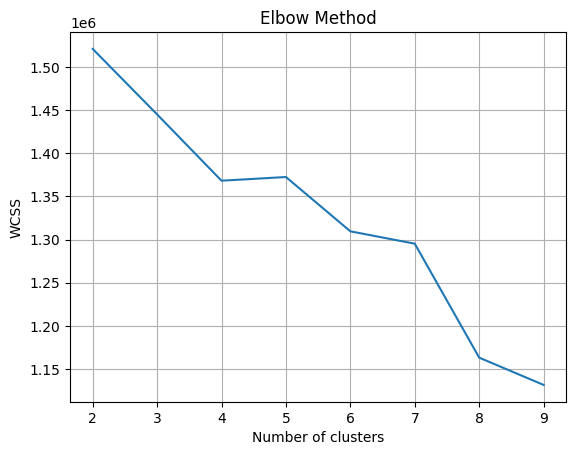

In [6]:
wcss = [] # Within-Cluster-Sum of Squares yang artinya jumlah total jarak antara setiap titik data dengan pusat klaster terdekatnya. WCSS digunakan untuk mengevaluasi seberapa baik klaster terbentuk, semakin kecil WCSS, semakin baik klaster terbentuk.
for i in range(2, 10): #ini artinya kita akan mencoba jumlah klaster dari 2 hingga 10 untuk melihat bagaimana WCSS berubah dengan jumlah klaster yang berbeda. Dengan melihat grafik WCSS, kita dapat menentukan jumlah klaster yang optimal menggunakan metode elbow.
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) #inertia untuk menghitung WCSS atau jumlah total jarak antara setiap titik data dengan pusat klaster terdekatnya.
plt.plot(range(2, 10), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette}")
print(f"KMeans Davies-Bouldin Score: {kmeans_davies_bouldin}")

KMeans Silhouette Score: 0.05452816317984716
KMeans Davies-Bouldin Score: 2.9937407566750807


In [8]:
dbscan = DBSCAN(eps = 1.5, min_samples = 5)
dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1
dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
dbscan_davies_bouldin = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")
print(f"DBSCAN Davies-Bouldin Score: {dbscan_davies_bouldin}")


DBSCAN Silhouette Score: 0.6261217058866495
DBSCAN Davies-Bouldin Score: 0.5239052031699405


In [9]:
#Hybrid
kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels2 = kmeans2.fit_predict(X_scaled)

dbscan2 = DBSCAN(eps = 1.5, min_samples = 5)
dbscan_labels2 = dbscan2.fit_predict(X_scaled)
hybrid_labels = np.where(dbscan_labels2 != -1, dbscan_labels2, kmeans_labels)

mask = hybrid_labels != -1
hybrid_silhouette = silhouette_score(X_scaled[mask], hybrid_labels[mask])
hybrid_davies_bouldin = davies_bouldin_score(X_scaled[mask], hybrid_labels[mask])
print(f"Hybrid Silhouette Score: {hybrid_silhouette}")
print(f"Hybrid Davies-Bouldin Score: {hybrid_davies_bouldin}")

Hybrid Silhouette Score: 0.45897877889963823
Hybrid Davies-Bouldin Score: 1.4616416690432008


In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

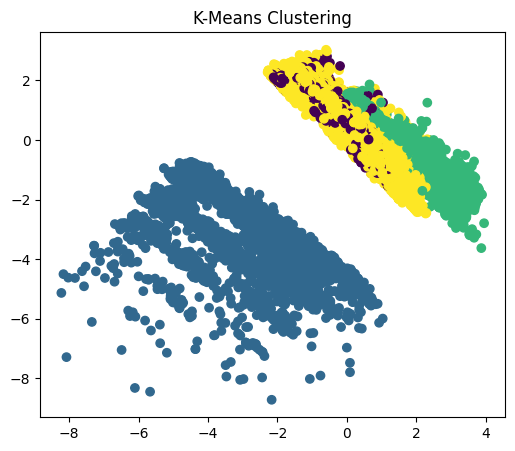

In [11]:
#KMEANS Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

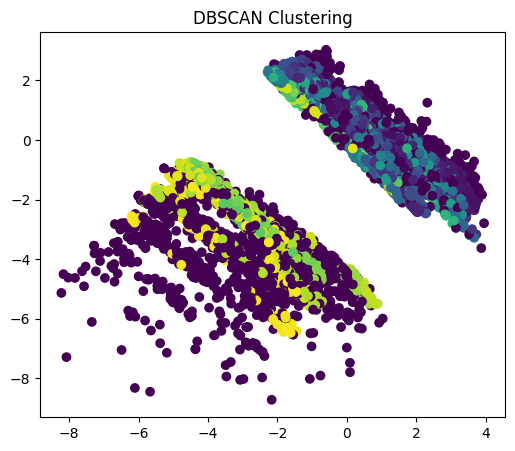

In [12]:
#DBSCAN Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

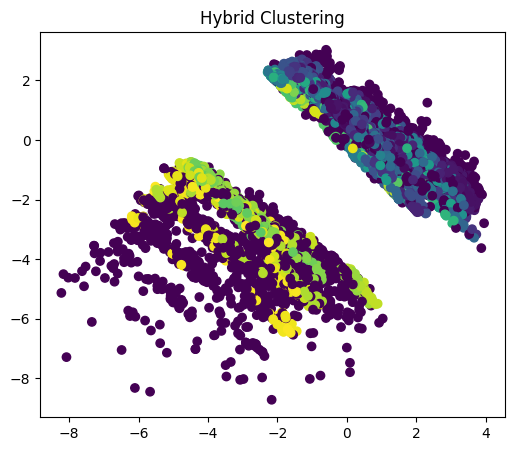

In [13]:
#Hybrid Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hybrid_labels)
plt.title("Hybrid Clustering")
plt.show()

In [14]:
results = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN", "Hybrid"],
    "Silhouette Score": [kmeans_silhouette, dbscan_silhouette, hybrid_silhouette],
    "DBI": [kmeans_davies_bouldin, dbscan_davies_bouldin, hybrid_davies_bouldin]
})

print(results)

     Model  Silhouette Score       DBI
0  K-Means          0.054528  2.993741
1   DBSCAN          0.626122  0.523905
2   Hybrid          0.458979  1.461642


In [15]:
df_scoring = data.copy()

df_scoring["housing"] = df_scoring["housing"].map({"yes":1,"no":0})
df_scoring["loan"] = df_scoring["loan"].map({"yes":1,"no":0})
df_scoring["default"] = df_scoring["default"].map({"yes":1,"no":0})

scaler_mm = MinMaxScaler()

df_scoring["campaign_norm"] = scaler_mm.fit_transform(df_scoring[["campaign"]])
df_scoring["previous_norm"] = scaler_mm.fit_transform(df_scoring[["previous"]])

# engagement
df_scoring["engagement_score"] = (
    0.6 * df_scoring["campaign_norm"] +
    0.4 * df_scoring["previous_norm"]
)

# risk
df_scoring["risk_score"] = (
    0.4 * df_scoring["loan"] +
    0.3 * df_scoring["housing"] +
    0.3 * df_scoring["default"]
)

# final score
df_scoring["final_score"] = (
    0.6 * df_scoring["engagement_score"] +
    0.4 * (1 - df_scoring["risk_score"])
)

In [16]:
def categorize(score):
    if score > 0.7:
        return "High Value"
    elif score > 0.4:
        return "Medium Value"
    else:
        return "Low Value"

df_scoring["category"] = df_scoring["final_score"].apply(categorize)

def strategy(row):
    if row["category"] == "High Value":
        return "Premium Targeting"
    elif row["category"] == "Medium Value":
        return "Cross-Selling"
    else:
        return "Promotion Campaign"

df_scoring["strategy"] = df_scoring.apply(strategy, axis=1)

In [17]:
results = {
    "kmeans_labels": kmeans_labels,
    "dbscan_labels": dbscan_labels,
    "hybrid_labels": hybrid_labels,
    "X_pca": X_pca,

    # evaluation metrics
    "evaluation": {
        "K-Means": {"silhouette": kmeans_silhouette, "dbi": kmeans_davies_bouldin},
        "DBSCAN": {"silhouette": dbscan_silhouette, "dbi": dbscan_davies_bouldin},
        "Hybrid": {"silhouette": hybrid_silhouette, "dbi": hybrid_davies_bouldin}
    }
}

with open("model_results.pkl", "wb") as f:
    pickle.dump(results, f)

with open("scoring_data.pkl", "wb") as f:
    pickle.dump(df_scoring, f)
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("dbscan_model.pkl", "wb") as f:
    pickle.dump(dbscan, f)